# Validation early stopping versus theta estimation

This notebook displays the second diagnostic experiment. The data are paired within each original Experiment 1 trajectory. Existing 15-checkpoint paths were replayed once with the same seeds to record all 1,000 epochs; stopping rules are applied retrospectively. The full available source has **10 repetitions per case**, not 100.

Run cells in order with the repository `.venv` kernel. By default, this notebook only reads completed results. Set `RUN_ANALYSIS = True` to regenerate tables and figures from completed dense trajectories without training. The README gives commands for recording dense paths from a new source run.

In [1]:
import sys, subprocess
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image
cwd = Path.cwd().resolve()
ROOT = next((p for p in (cwd, *cwd.parents) if (p/'dqAux.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside the dplqr repository.')
EXPERIMENT_DIR = ROOT/'results/2026-09-08-early-stopping-vs-theta'
RUN_ANALYSIS = False
CASE_TO_DISPLAY = 1  # 1: linear; 2: additive; 3: deep
print('Interpreter:', sys.executable)
print('Result folder:', EXPERIMENT_DIR)

Interpreter: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\.venv\Scripts\python.exe
Result folder: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-08-early-stopping-vs-theta


In [2]:
if RUN_ANALYSIS:
    subprocess.run([sys.executable, str(EXPERIMENT_DIR/'scripts/run_diagnostic.py'),
                    '--stage', 'analyze', '--output-dir', str(EXPERIMENT_DIR)], check=True)
required = ['monte_carlo_summary_patience.csv', 'monte_carlo_summary_max_epochs.csv',
            'oracle_epoch_summary.csv', 'paired_max_epoch_comparisons.csv']
for filename in required:
    path = EXPERIMENT_DIR/filename
    if not path.is_file():
        raise FileNotFoundError(f'{path} is missing. Run the README smoke/all commands first.')
    frame = pd.read_csv(path)
    display(Markdown('### ' + filename))
    display(frame.loc[frame.case.eq(CASE_TO_DISPLAY)])

### monte_carlo_summary_patience.csv

,case,analysis,rule_id,patience,max_epochs,case_name,repetitions,mc_sd_available,restore_best,min_delta,...,theta_2_bias_mcse,theta_2_rmse,theta_vector_rmse,proportion_early_stopping,proportion_max_epochs,proportion_before_theta_oracle,proportion_equal_theta_oracle,proportion_after_theta_oracle,proportion_within_10_epochs,proportion_within_25_epochs
0,1,patience,patience_100,100,1000,linear,10,True,True,0.0,...,0.074485,0.532026,0.563336,1.0,0.0,1.0,0.0,0.0,0.1,0.1
1,1,patience,patience_15,15,1000,linear,10,True,True,0.0,...,0.063719,0.613841,0.668913,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1,patience,patience_200,200,1000,linear,10,True,True,0.0,...,0.074485,0.532026,0.563336,1.0,0.0,1.0,0.0,0.0,0.1,0.1
3,1,patience,patience_30,30,1000,linear,10,True,True,0.0,...,0.074485,0.532026,0.563336,1.0,0.0,1.0,0.0,0.0,0.1,0.1
4,1,patience,patience_5,5,1000,linear,10,True,True,0.0,...,0.083675,0.888913,1.000031,1.0,0.0,1.0,0.0,0.0,0.0,0.0
5,1,patience,patience_50,50,1000,linear,10,True,True,0.0,...,0.074485,0.532026,0.563336,1.0,0.0,1.0,0.0,0.0,0.1,0.1


### monte_carlo_summary_max_epochs.csv

,case,analysis,rule_id,patience,max_epochs,case_name,repetitions,mc_sd_available,restore_best,min_delta,...,theta_2_bias_mcse,theta_2_rmse,theta_vector_rmse,proportion_early_stopping,proportion_max_epochs,proportion_before_theta_oracle,proportion_equal_theta_oracle,proportion_after_theta_oracle,proportion_within_10_epochs,proportion_within_25_epochs
0,1,max_epochs,max_epochs_100,15,100,linear,10,True,True,0.0,...,0.063719,0.613841,0.668913,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,max_epochs,max_epochs_1000,15,1000,linear,10,True,True,0.0,...,0.063719,0.613841,0.668913,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1,max_epochs,max_epochs_200,15,200,linear,10,True,True,0.0,...,0.063719,0.613841,0.668913,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,max_epochs,max_epochs_25,15,25,linear,10,True,True,0.0,...,0.113140,1.008910,1.132766,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1,max_epochs,max_epochs_50,15,50,linear,10,True,True,0.0,...,0.077585,0.765031,0.840085,0.1,0.9,1.0,0.0,0.0,0.0,0.0
5,1,max_epochs,max_epochs_500,15,500,linear,10,True,True,0.0,...,0.063719,0.613841,0.668913,1.0,0.0,1.0,0.0,0.0,0.0,0.0


### oracle_epoch_summary.csv

,case,case_name,repetitions,mc_sd_available,mean_e_theta,median_e_theta,sd_e_theta,mcse_e_theta,q25_e_theta,q75_e_theta,...,sd_oracle_stopping_validation_check_loss,mcse_oracle_stopping_validation_check_loss,q25_oracle_stopping_validation_check_loss,q75_oracle_stopping_validation_check_loss,mean_e_q_minus_e_theta,mean_abs_e_q_minus_e_theta,mean_e_m_minus_e_theta,mean_abs_e_m_minus_e_theta,mean_e_test_minus_e_theta,mean_abs_e_test_minus_e_theta
0,1,linear,10,True,353.3,292.0,242.537992,76.697248,189.0,404.0,...,0.037132,0.011742,0.533325,0.57405,-289.0,289.0,-282.0,282.0,-283.8,283.8


### paired_max_epoch_comparisons.csv

,case,case_name,max_epochs,reference_max_epochs,repetitions,same_selected_epoch_count,proportion_same_selected_epoch,exactly_same_coefficients_count,mean_coefficient_difference_l2,max_coefficient_difference_l2,mean_paired_selected_epoch_difference,mcse_paired_selected_epoch_difference,mean_paired_theta_error_l2_difference,mcse_paired_theta_error_l2_difference,mean_paired_test_check_loss_difference,mcse_paired_test_check_loss_difference,mean_paired_q_l2_error_difference,mcse_paired_q_l2_error_difference
0,1,linear,25,1000,10,1,0.1,1,0.447510,0.910117,-30.8,5.697563,0.433713,0.094252,0.016660,0.004298,0.092983,0.024031
1,1,linear,50,1000,10,4,0.4,4,0.167039,0.397717,-13.8,3.940671,0.163993,0.052043,0.002612,0.001389,0.015130,0.008435
2,1,linear,100,1000,10,10,1.0,10,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,linear,200,1000,10,10,1.0,10,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1,linear,500,1000,10,10,1.0,10,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,1,linear,1000,1000,10,10,1.0,10,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Figures for the chosen case

A: coefficient RMSE versus patience. B: selected epoch versus patience. C: selected epoch versus the cap. D: prediction error versus coefficient error. E: validation-selected epoch versus the infeasible theta oracle.

The validation rule restores the earliest strict best checkpoint. Its criterion averages the two validation batch losses equally (128 and 72 observations); the ordinary empirical validation mean is also retained. Oracle epochs never affect this decision. These figures diagnose estimation; they do not measure confidence-interval coverage.

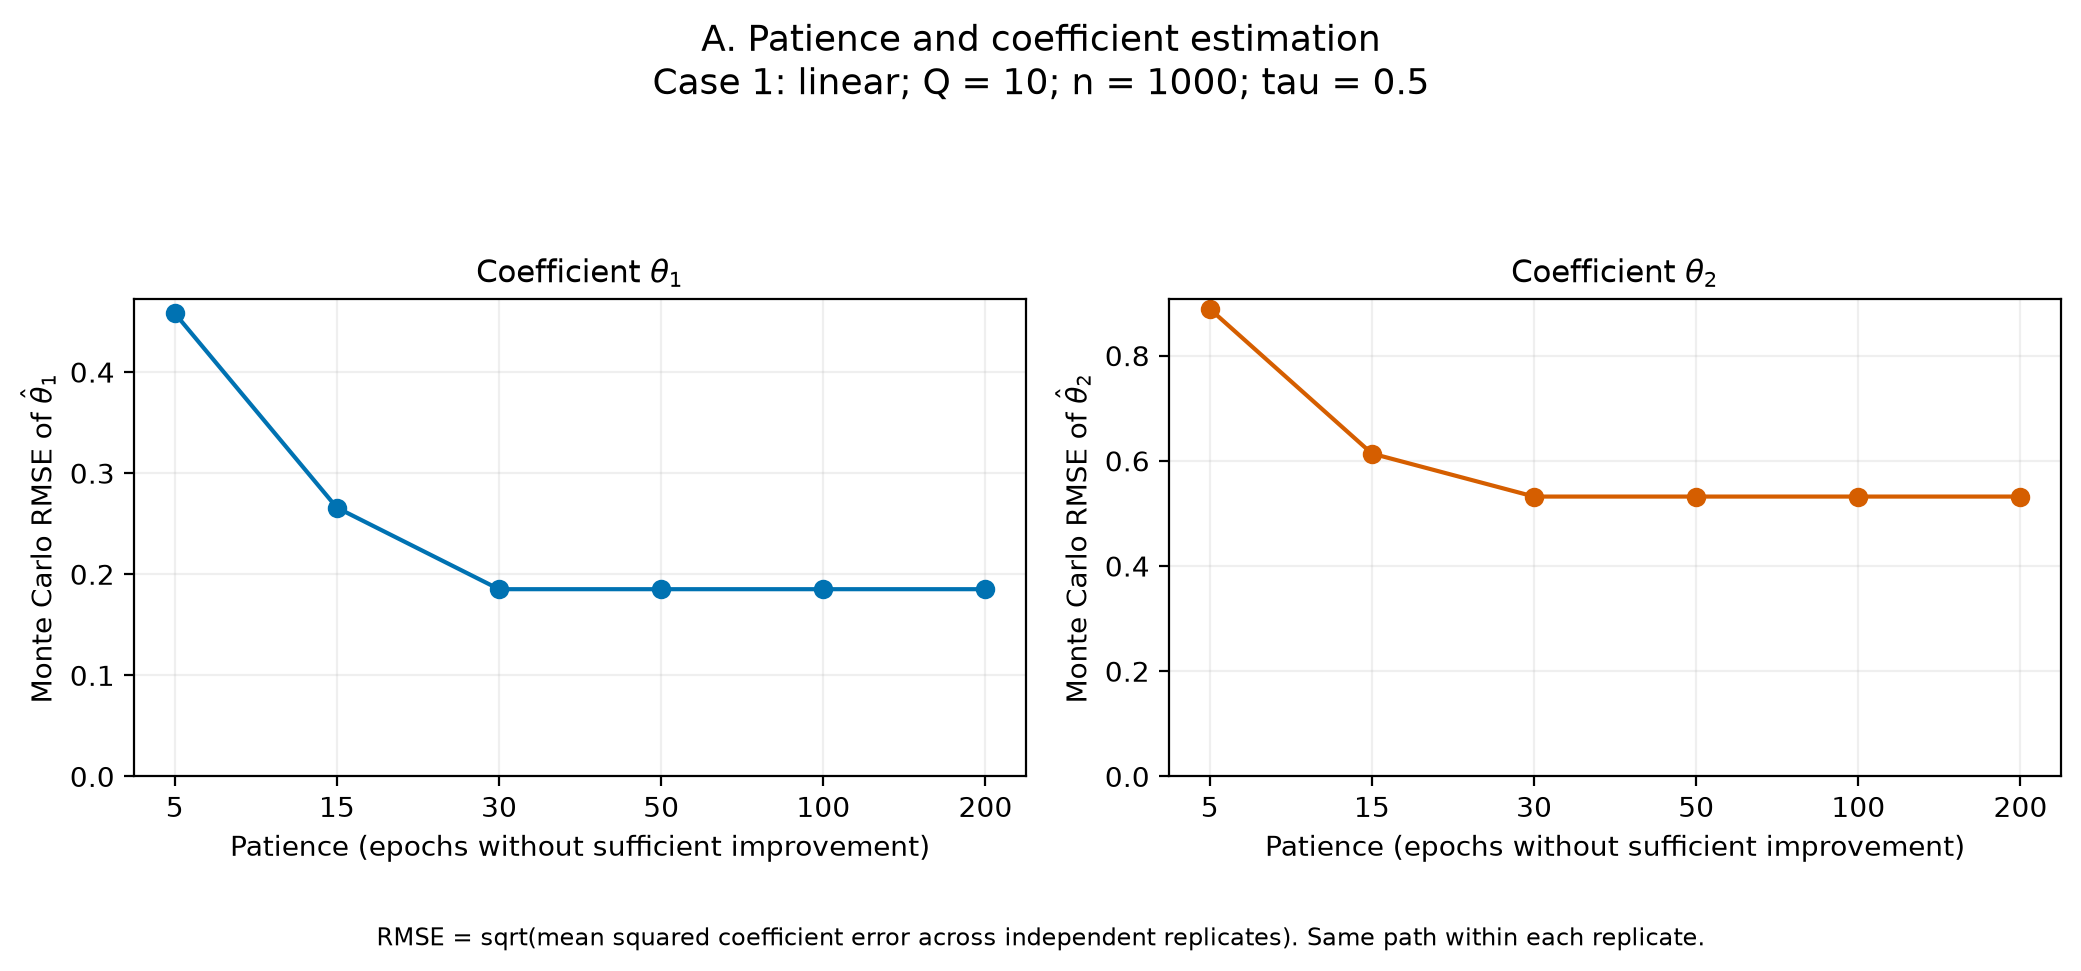

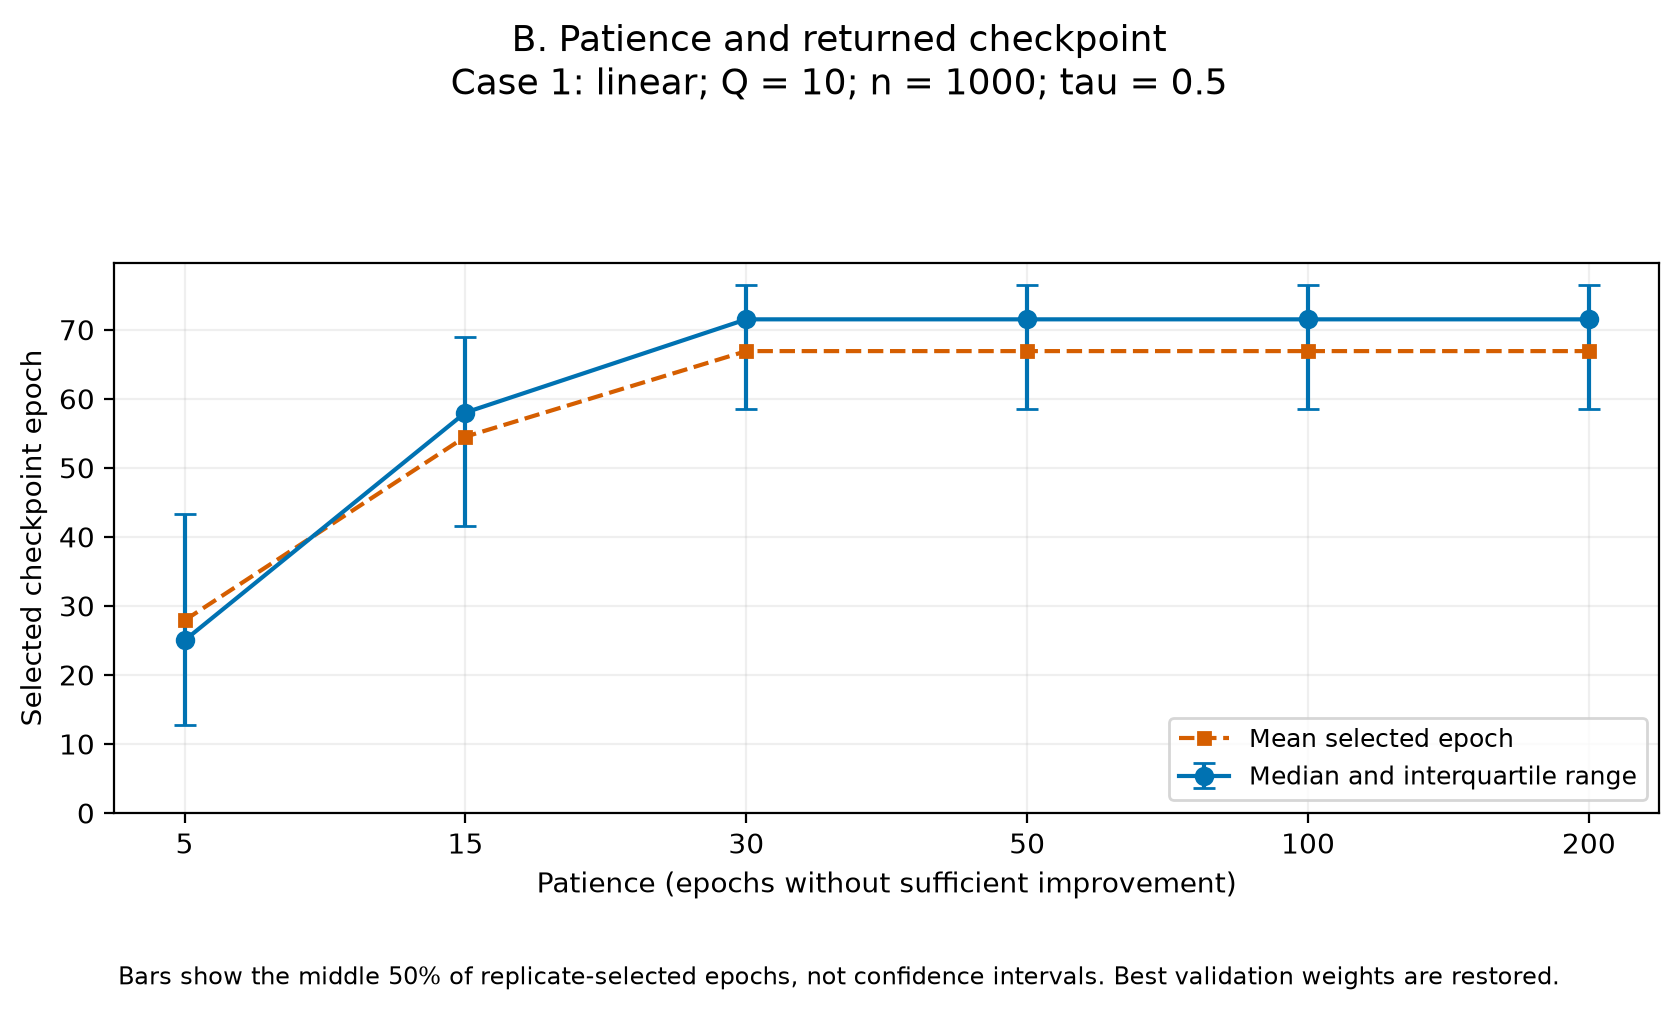

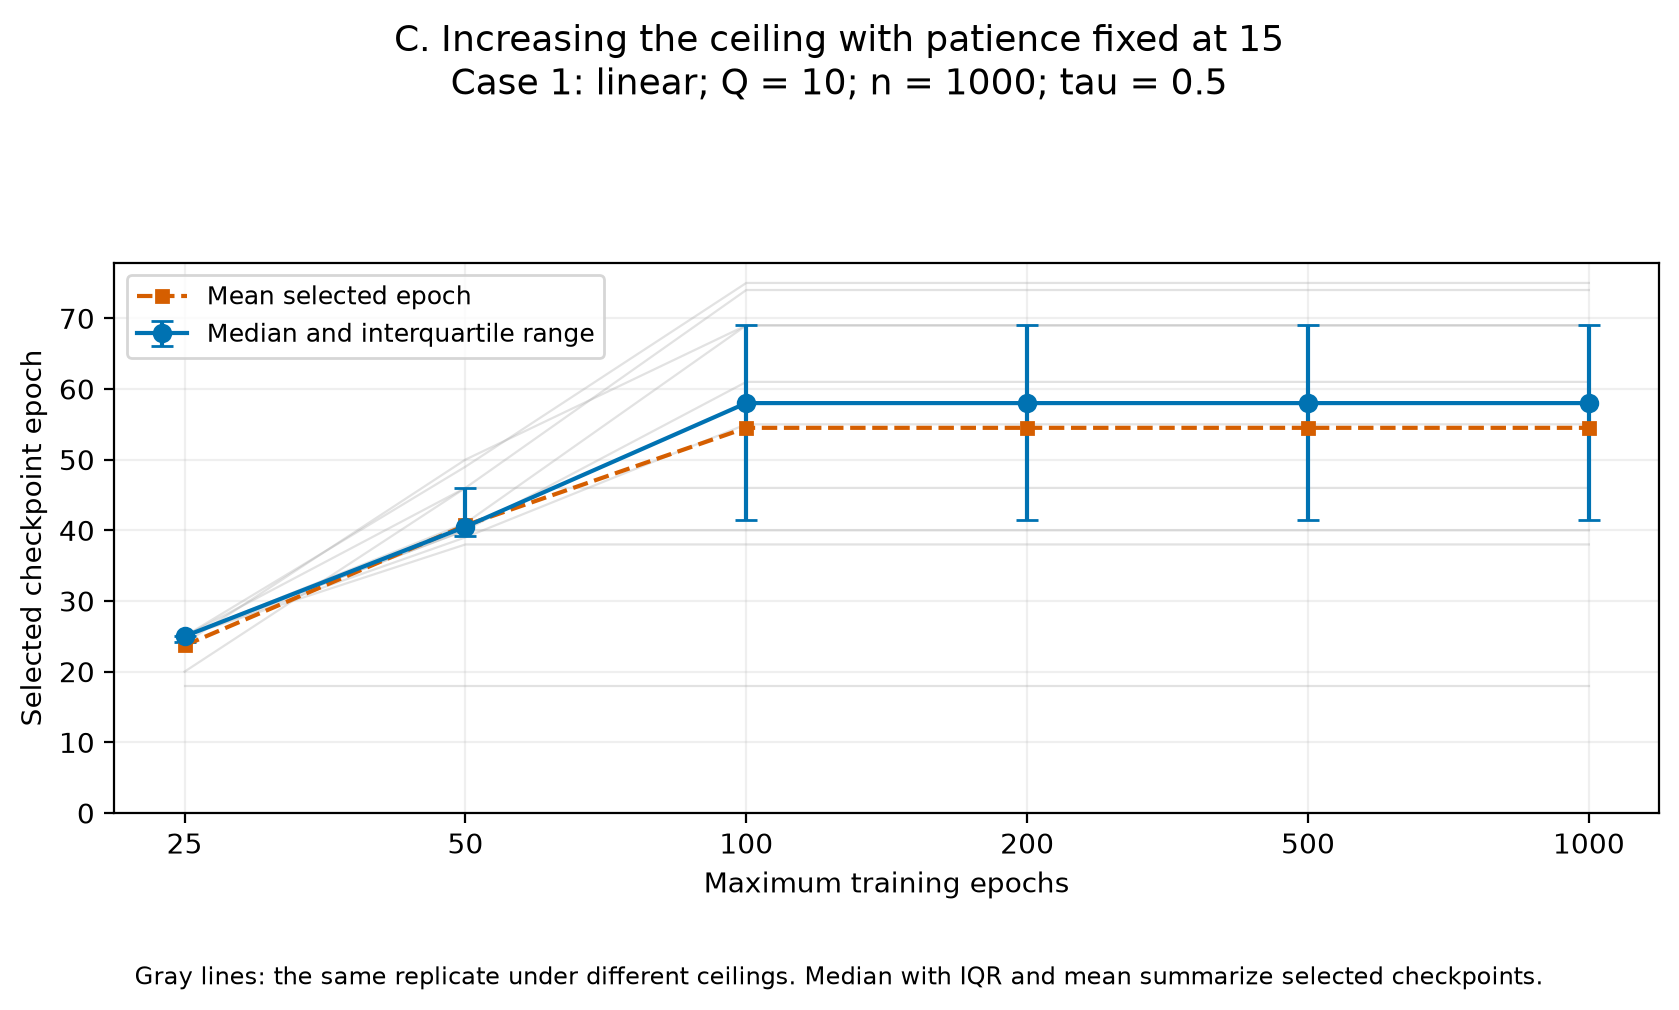

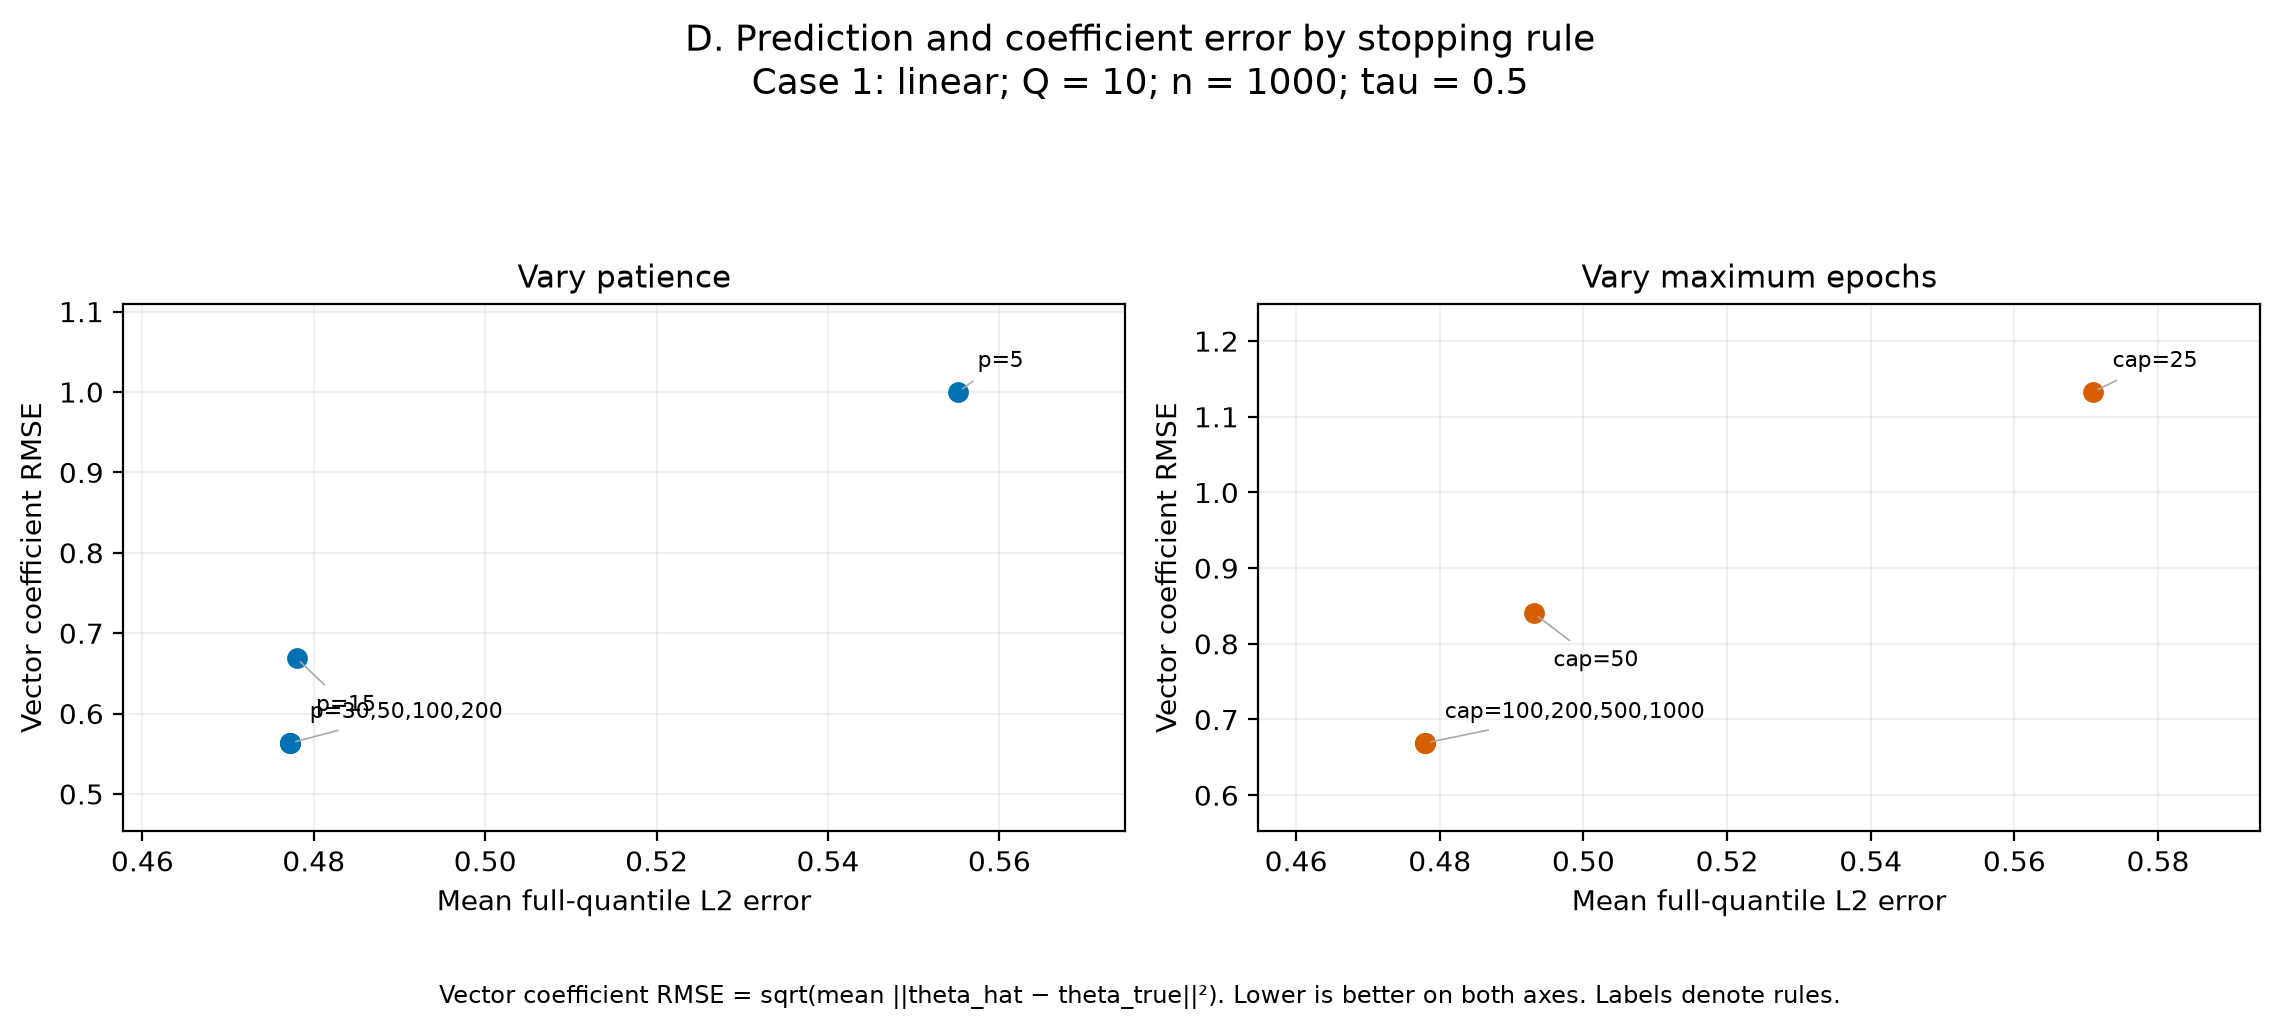

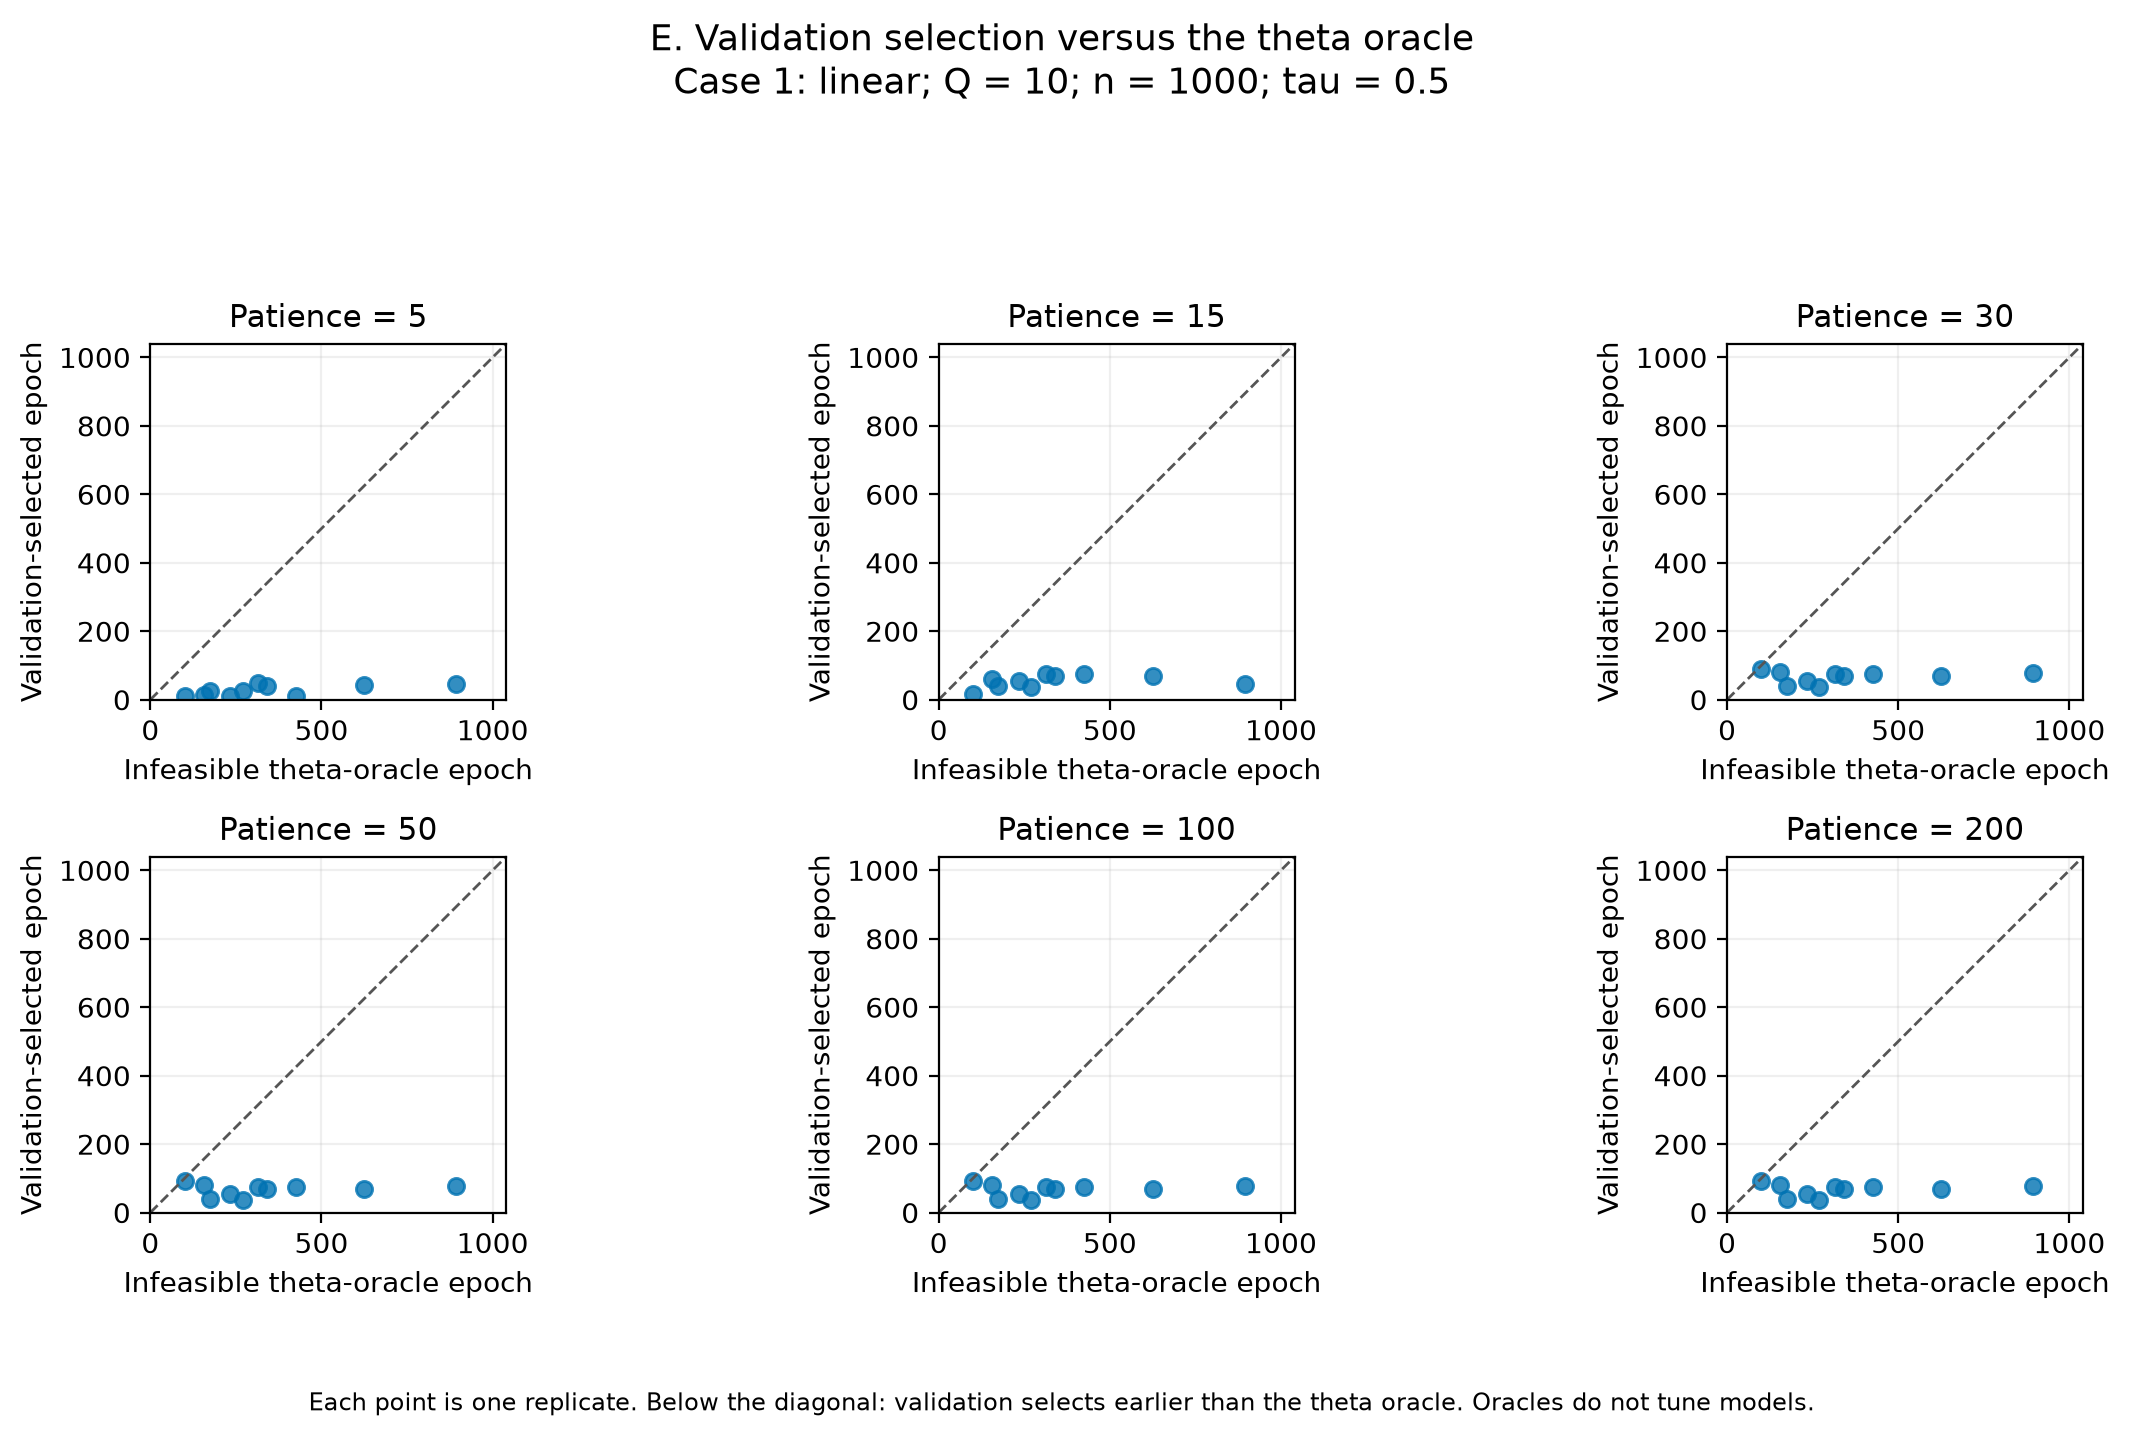

In [3]:
figures = sorted((EXPERIMENT_DIR/'figures').glob(f'case_{CASE_TO_DISPLAY}_*.png'))
if not figures:
    raise FileNotFoundError('No figures found; run the analysis command from the README.')
for figure in figures:
    display(Image(filename=str(figure)))